In [1]:
import matplotlib.pyplot as plt

import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [2]:
import numpy as np
from scipy.integrate import solve_ivp


def lee_ng_rhs(N, y, nu_s, nu_slip):
    """
    Lee-Ng equations using turn number N as the
    independent variable.

    y[0] = phi
    y[1] = p
    """
    phi, p = y

    slip_phase = 2 * np.pi * nu_slip * N

    dphi_dN = 2 * np.pi * nu_s * p

    dp_dN = -2 * np.pi * nu_s * (
        np.sin(phi)
        + np.sin(phi - slip_phase)
    )

    return [dphi_dN, dp_dN]


# Example Recycler-like parameters
nu_s = 0.00235
nu_slip = 0.0140

# Initial conditions
phi0 = 0.02
p0 = 0.0

turns = np.linspace(0, 1000, 50_001)

solution = solve_ivp(
    lee_ng_rhs,
    t_span=(turns[0], turns[-1]),
    y0=[phi0, p0],
    t_eval=turns,
    args=(nu_s, nu_slip),
    method="DOP853",
    rtol=1e-11,
    atol=1e-13,
    max_step=0.1,
)

phi = solution.y[0]
p = solution.y[1]

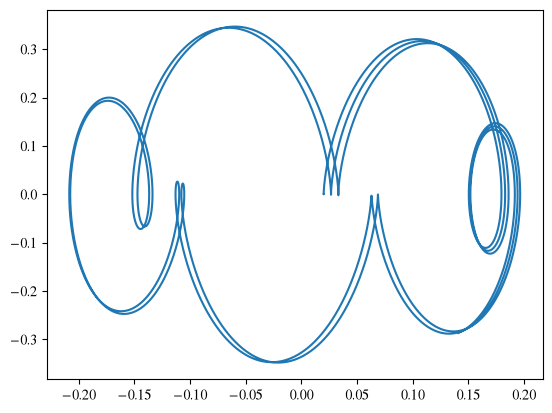

In [3]:
plt.plot(phi, p)

In [4]:
# Use the regular inline backend in VS Code
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


# ============================================================
# Lee-Ng parameters
# ============================================================

nu_s = 0.00235
nu_slip = 0.0140

alpha_s = nu_slip / nu_s
N_slip = 1.0 / abs(nu_slip)

print(f"Slip-stacking parameter: alpha_s = {alpha_s:.3f}")
print(f"Slip period: N_slip = {N_slip:.3f} turns")


# ============================================================
# Phase-space grid
# ============================================================

phi_min, phi_max = -np.pi, np.pi
p_min, p_max = -18.0, 18.0

phi_values = np.linspace(phi_min, phi_max, 301)
p_values = np.linspace(p_min, p_max, 301)

PHI, P = np.meshgrid(phi_values, p_values)


# ============================================================
# Lee-Ng two-RF Hamiltonian
# ============================================================

def lee_ng_hamiltonian(phi, p, turn, nu_s, nu_slip):
    """
    Lee-Ng two-RF Hamiltonian.

    Parameters
    ----------
    phi : array-like
        RF phase.
    p : array-like
        Normalized momentum.
    turn : float
        Turn number N.
    nu_s : float
        Small-amplitude synchrotron tune.
    nu_slip : float
        Slip-stacking tune.

    Returns
    -------
    H : array-like
        Hamiltonian evaluated at the requested turn.
    """

    theta = 2.0 * np.pi * turn

    return nu_s * (
        0.5 * p**2
        + 2.0
        - np.cos(phi)
        - np.cos(phi - nu_slip * theta)
    )


# Fixed contour levels keep the color scale constant
# as the time slider changes.
H_normalized_max = 0.5 * p_max**2 + 4.0

levels = np.unique(
    np.concatenate(
        [
            np.linspace(0.0, 6.0, 31),
            np.linspace(6.0, H_normalized_max, 25),
        ]
    )
)


# ============================================================
# Plotting function
# ============================================================

def plot_hamiltonian(turn):
    theta = 2.0 * np.pi * turn

    relative_rf_phase = np.mod(
        nu_slip * theta,
        2.0 * np.pi,
    )

    H = lee_ng_hamiltonian(
        PHI,
        P,
        turn,
        nu_s,
        nu_slip,
    )

    # H/nu_s has the same contours as H but cleaner values.
    H_normalized = H / nu_s

    fig, ax = plt.subplots(
        figsize=(9, 6),
        constrained_layout=True,
    )

    filled_contours = ax.contourf(
        PHI,
        P,
        H_normalized,
        levels=levels,
        cmap="turbo",
        extend="max",
    )

    ax.contour(
        PHI,
        P,
        H_normalized,
        levels=levels,
        colors="black",
        linewidths=0.35,
        alpha=0.55,
    )

    ax.set_xlim(phi_min, phi_max)
    ax.set_ylim(p_min, p_max)

    ax.set_xticks(
        [
            -np.pi,
            -np.pi / 2,
            0,
            np.pi / 2,
            np.pi,
        ],
        [
            r"$-\pi$",
            r"$-\pi/2$",
            r"$0$",
            r"$\pi/2$",
            r"$\pi$",
        ],
    )

    ax.set_xlabel(r"RF phase $\phi$ [rad]")
    ax.set_ylabel(r"Normalized momentum $p$")

    ax.set_title(
        rf"Lee--Ng two-RF Hamiltonian at $N={turn:.2f}$ turns"
        "\n"
        rf"$\nu_{{\mathrm{{slip}}}}\theta"
        rf"\ \mathrm{{mod}}\ 2\pi"
        rf"={relative_rf_phase:.3f}\ \mathrm{{rad}}$"
    )

    ax.grid(alpha=0.15)

    colorbar = fig.colorbar(
        filled_contours,
        ax=ax,
    )

    colorbar.set_label(r"$H/\nu_s$")

    plt.show()

    # Prevent accumulation of old figures as the slider moves.
    plt.close(fig)


# ============================================================
# VS Code-compatible interactive control
# ============================================================

turn_slider = widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=250.0,
    step=0.25,
    description="Turn N:",
    readout_format=".2f",
    continuous_update=False,
    layout=widgets.Layout(width="800px"),
)

# interactive_output returns an Output widget.
# Unlike fig.canvas, this can safely be placed inside a VBox.
plot_output = widgets.interactive_output(
    plot_hamiltonian,
    {"turn": turn_slider},
)

display(
    widgets.VBox(
        [
            turn_slider,
            plot_output,
        ]
    )
)

Slip-stacking parameter: alpha_s = 5.957
Slip period: N_slip = 71.429 turns


In [5]:
def lee_ng_rhs_many(N, y, nu_s, nu_slip):
    """
    Lee-Ng equations for multiple particles.

    The flattened state is

        y = [phi_0, p_0, phi_1, p_1, ...]

    Parameters
    ----------
    N : float
        Turn number.
    y : ndarray
        Flattened particle coordinates.
    nu_s : float
        Small-amplitude synchrotron tune.
    nu_slip : float
        Slip-stacking tune.
    """

    particles = y.reshape(-1, 2)

    phi = particles[:, 0]
    p = particles[:, 1]

    slip_phase = 2.0 * np.pi * nu_slip * N

    derivatives = np.empty_like(particles)

    derivatives[:, 0] = 2.0 * np.pi * nu_s * p

    derivatives[:, 1] = -2.0 * np.pi * nu_s * (
        np.sin(phi)
        + np.sin(phi - slip_phase)
    )

    return derivatives.ravel()

In [6]:
# ------------------------------------------------------------
# Machine parameters
# ------------------------------------------------------------

nu_s = 0.00235
nu_slip = 0.0140

alpha_s = nu_slip / nu_s
N_slip = 1.0 / abs(nu_slip)

print(f"alpha_s = {alpha_s:.4f}")
print(f"Slip period = {N_slip:.4f} turns")


# ------------------------------------------------------------
# Initial conditions
# ------------------------------------------------------------

# Start particles at different phase amplitudes.
# These are approximately turning points of the oscillations.
phase_amplitudes = np.array([
    0.02,
    0.30,
    0.60,
    1.00,
    1.40,
    1.80,
])

n_per_family = len(phase_amplitudes)


# Stationary RF bucket:
# center approximately at (phi, p) = (0, 0)
stationary_initial_conditions = np.column_stack(
    [
        phase_amplitudes,
        np.zeros(n_per_family),
    ]
)


# Moving RF bucket:
# at N=0, its center is approximately
# (phi, p) = (0, alpha_s)
moving_initial_conditions = np.column_stack(
    [
        phase_amplitudes,
        np.full(n_per_family, alpha_s),
    ]
)


initial_conditions = np.vstack(
    [
        stationary_initial_conditions,
        moving_initial_conditions,
    ]
)

n_particles = len(initial_conditions)

stationary_indices = np.arange(n_per_family)
moving_indices = np.arange(
    n_per_family,
    2 * n_per_family,
)

print("Stationary-bucket initial conditions:")
print(stationary_initial_conditions)

print("\nMoving-bucket initial conditions:")
print(moving_initial_conditions)

alpha_s = 5.9574
Slip period = 71.4286 turns
Stationary-bucket initial conditions:
[[0.02 0.  ]
 [0.3  0.  ]
 [0.6  0.  ]
 [1.   0.  ]
 [1.4  0.  ]
 [1.8  0.  ]]

Moving-bucket initial conditions:
[[0.02       5.95744681]
 [0.3        5.95744681]
 [0.6        5.95744681]
 [1.         5.95744681]
 [1.4        5.95744681]
 [1.8        5.95744681]]


In [7]:
# ------------------------------------------------------------
# Integrate
# ------------------------------------------------------------

N_max = 5000.0

turns = np.linspace(
    0.0,
    N_max,
    50_001,
)

multi_solution = solve_ivp(
    lee_ng_rhs_many,
    t_span=(turns[0], turns[-1]),
    y0=initial_conditions.ravel(),
    t_eval=turns,
    args=(nu_s, nu_slip),
    method="DOP853",
    rtol=1e-11,
    atol=1e-13,
    max_step=0.5,
    dense_output=True,
)

if not multi_solution.success:
    raise RuntimeError(multi_solution.message)


# Shape:
# (number of turns, number of particles, 2)
trajectories = multi_solution.y.T.reshape(
    len(turns),
    n_particles,
    2,
)

phi = trajectories[:, :, 0]
p = trajectories[:, :, 1]

print("Trajectory-array shape:", trajectories.shape)

Trajectory-array shape: (50001, 12, 2)


In [8]:
def wrap_phase(angle):
    """Wrap an angle to [-pi, pi)."""
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


slip_phase = (
    2.0
    * np.pi
    * nu_slip
    * turns[:, np.newaxis]
)


# Coordinates in the stationary RF frame
phi_stationary_frame = wrap_phase(phi)
p_stationary_frame = p


# Coordinates in the moving RF frame
phi_moving_frame = wrap_phase(
    phi - slip_phase
)

p_moving_frame = p - alpha_s

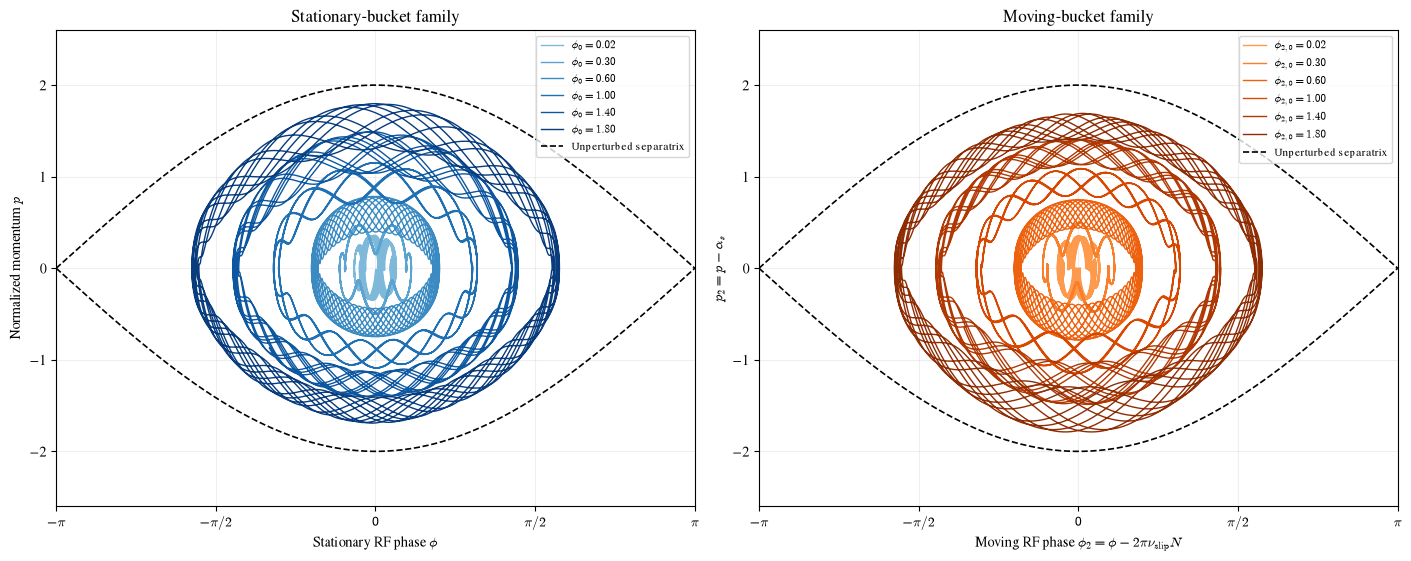

In [9]:
import matplotlib.pyplot as plt


def periodic_line_data(angle, momentum):
    """
    Insert NaNs when the phase wraps through +/- pi,
    preventing lines across the entire plot.
    """

    wrapped_angle = wrap_phase(angle).astype(float)
    momentum = np.asarray(momentum, dtype=float).copy()

    jumps = np.r_[
        False,
        np.abs(np.diff(wrapped_angle)) > np.pi,
    ]

    wrapped_angle[jumps] = np.nan
    momentum[jumps] = np.nan

    return wrapped_angle, momentum


# Unperturbed single-RF separatrix:
#
#     p_sep = +/- 2 cos(phi/2)
#
phi_separatrix = np.linspace(-np.pi, np.pi, 500)
p_separatrix = 2.0 * np.cos(phi_separatrix / 2.0)


stationary_colors = plt.cm.Blues(
    np.linspace(0.45, 0.95, n_per_family)
)

moving_colors = plt.cm.Oranges(
    np.linspace(0.45, 0.95, n_per_family)
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    constrained_layout=True,
)

# Plot fewer points for faster rendering
plot_stride = 5


# ------------------------------------------------------------
# Stationary bucket in the stationary RF frame
# ------------------------------------------------------------

for color, particle_index, phi0 in zip(
    stationary_colors,
    stationary_indices,
    phase_amplitudes,
):
    phase_plot, momentum_plot = periodic_line_data(
        phi_stationary_frame[
            ::plot_stride,
            particle_index,
        ],
        p_stationary_frame[
            ::plot_stride,
            particle_index,
        ],
    )

    axes[0].plot(
        phase_plot,
        momentum_plot,
        color=color,
        linewidth=1.0,
        label=rf"$\phi_0={phi0:.2f}$",
    )


axes[0].plot(
    phi_separatrix,
    p_separatrix,
    "--",
    color="black",
    linewidth=1.2,
    label="Unperturbed separatrix",
)

axes[0].plot(
    phi_separatrix,
    -p_separatrix,
    "--",
    color="black",
    linewidth=1.2,
)

axes[0].set_title("Stationary-bucket family")
axes[0].set_xlabel(r"Stationary RF phase $\phi$")
axes[0].set_ylabel(r"Normalized momentum $p$")
axes[0].set_xlim(-np.pi, np.pi)
axes[0].set_ylim(-2.6, 2.6)
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)


# ------------------------------------------------------------
# Moving bucket in its co-moving RF frame
# ------------------------------------------------------------

for color, particle_index, phi0 in zip(
    moving_colors,
    moving_indices,
    phase_amplitudes,
):
    phase_plot, momentum_plot = periodic_line_data(
        phi_moving_frame[
            ::plot_stride,
            particle_index,
        ],
        p_moving_frame[
            ::plot_stride,
            particle_index,
        ],
    )

    axes[1].plot(
        phase_plot,
        momentum_plot,
        color=color,
        linewidth=1.0,
        label=rf"$\phi_{{2,0}}={phi0:.2f}$",
    )


axes[1].plot(
    phi_separatrix,
    p_separatrix,
    "--",
    color="black",
    linewidth=1.2,
    label="Unperturbed separatrix",
)

axes[1].plot(
    phi_separatrix,
    -p_separatrix,
    "--",
    color="black",
    linewidth=1.2,
)

axes[1].set_title("Moving-bucket family")
axes[1].set_xlabel(
    r"Moving RF phase "
    r"$\phi_2=\phi-2\pi\nu_{\mathrm{slip}}N$"
)
axes[1].set_ylabel(
    r"$p_2=p-\alpha_s$"
)
axes[1].set_xlim(-np.pi, np.pi)
axes[1].set_ylim(-2.6, 2.6)
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)


for ax in axes:
    ax.set_xticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
        [
            r"$-\pi$",
            r"$-\pi/2$",
            r"$0$",
            r"$\pi/2$",
            r"$\pi$",
        ],
    )

plt.show()

In [10]:
# Exact stroboscopic times
number_of_slip_periods = int(
    np.floor(N_max / N_slip)
)

strobe_turns = (
    np.arange(number_of_slip_periods + 1)
    * N_slip
)


# Evaluate the dense numerical solution at the exact
# stroboscopic times.
strobe_states = multi_solution.sol(strobe_turns).T.reshape(
    len(strobe_turns),
    n_particles,
    2,
)

strobe_phi = wrap_phase(
    strobe_states[:, :, 0]
)

strobe_p = strobe_states[:, :, 1]

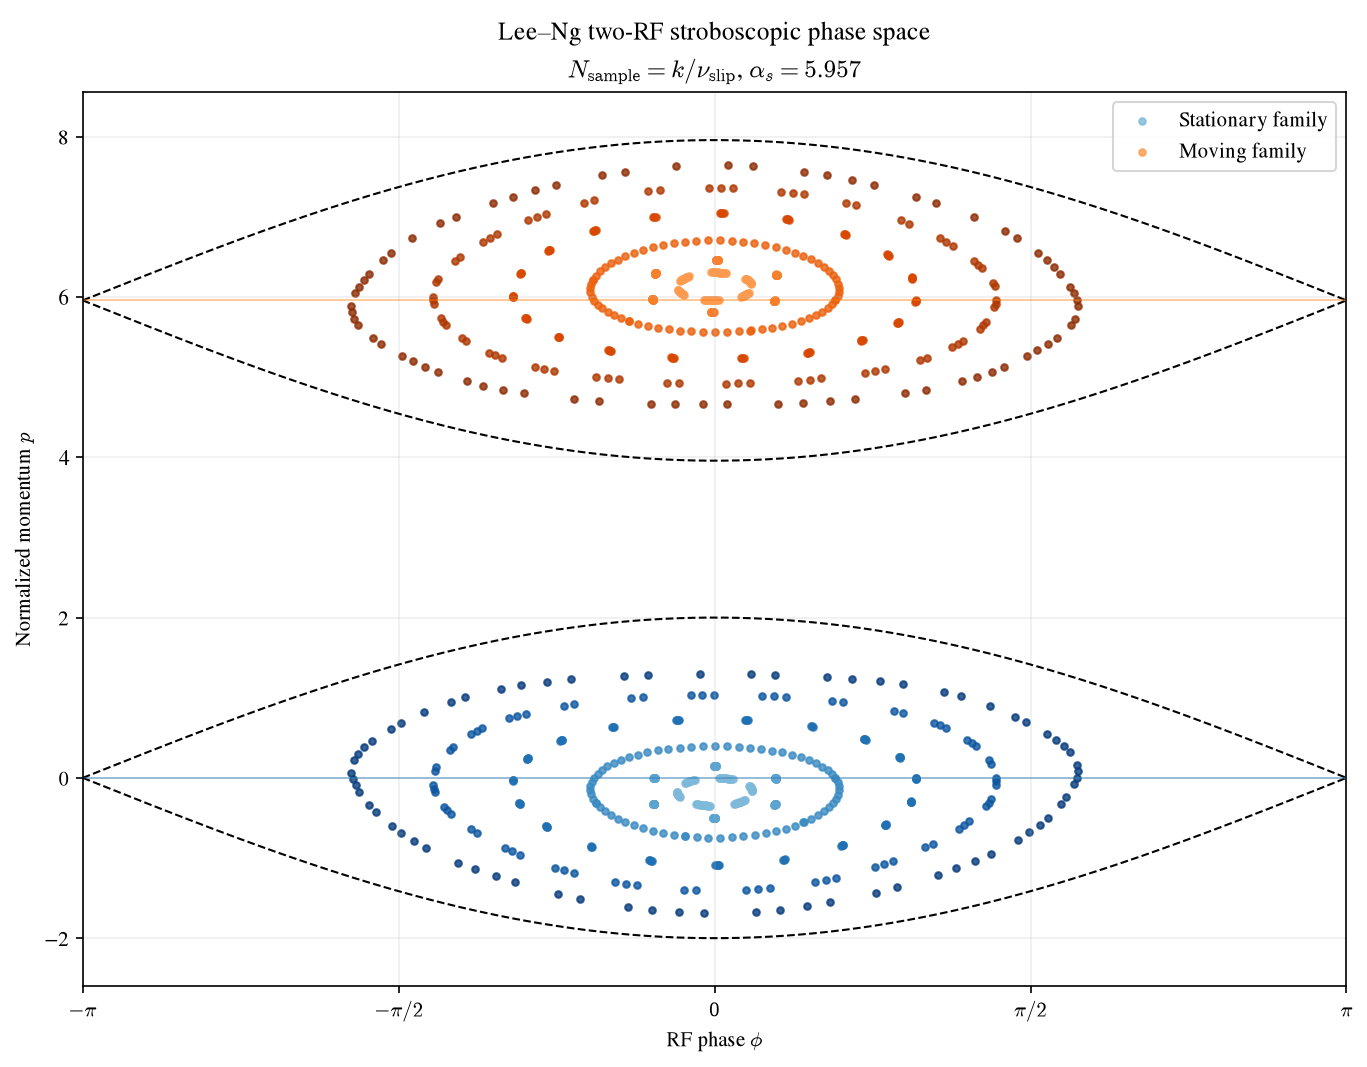

In [24]:
fig, ax = plt.subplots(
    figsize=(9, 7),
    constrained_layout=True,
)


# Stationary family
for i, particle_index in enumerate(stationary_indices):
    ax.scatter(
        strobe_phi[:, particle_index],
        strobe_p[:, particle_index],
        s=10,
        color=stationary_colors[i],
        alpha=0.8,
        label=(
            "Stationary family"
            if i == 0
            else None
        ),
    )


# Moving family
for i, particle_index in enumerate(moving_indices):
    ax.scatter(
        strobe_phi[:, particle_index],
        strobe_p[:, particle_index],
        s=10,
        color=moving_colors[i],
        alpha=0.8,
        label=(
            "Moving family"
            if i == 0
            else None
        ),
    )


# Unperturbed stationary bucket
ax.plot(
    phi_separatrix,
    p_separatrix,
    "--",
    color="black",
    linewidth=1.0,
)

ax.plot(
    phi_separatrix,
    -p_separatrix,
    "--",
    color="black",
    linewidth=1.0,
)


# Unperturbed moving bucket
ax.plot(
    phi_separatrix,
    alpha_s + p_separatrix,
    "--",
    color="black",
    linewidth=1.0,
)

ax.plot(
    phi_separatrix,
    alpha_s - p_separatrix,
    "--",
    color="black",
    linewidth=1.0,
)


ax.axhline(
    0.0,
    color="tab:blue",
    linewidth=0.8,
    alpha=0.5,
)

ax.axhline(
    alpha_s,
    color="tab:orange",
    linewidth=0.8,
    alpha=0.5,
)


ax.set_xlim(-np.pi, np.pi)

ax.set_ylim(
    min(-2.6, alpha_s - 2.6),
    max(2.6, alpha_s + 2.6),
)

ax.set_xticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    [
        r"$-\pi$",
        r"$-\pi/2$",
        r"$0$",
        r"$\pi/2$",
        r"$\pi$",
    ],
)

ax.set_xlabel(r"RF phase $\phi$")
ax.set_ylabel(r"Normalized momentum $p$")

ax.set_title(
    "Lee–Ng two-RF stroboscopic phase space\n"
    rf"$N_{{\mathrm{{sample}}}}=k/\nu_{{\mathrm{{slip}}}}$, "
    rf"$\alpha_s={alpha_s:.3f}$"
)

ax.grid(alpha=0.2)
ax.legend()

fig.set_dpi(150)
plt.show()

In [12]:
def sample_captured_bunch(
    n_particles,
    p_center,
    sigma_phi,
    sigma_p,
    rng,
    maximum_bucket_hamiltonian=1.2,
):
    """
    Sample a Gaussian bunch truncated inside an approximate
    single-RF bucket.

    The unperturbed normalized single-RF Hamiltonian is

        H0 / nu_s = dp**2 / 2 + 1 - cos(dphi),

    with separatrix value H0 / nu_s = 2.
    """

    accepted_particles = []

    number_accepted = 0

    while number_accepted < n_particles:
        number_to_generate = max(
            2 * (n_particles - number_accepted),
            256,
        )

        delta_phi = rng.normal(
            loc=0.0,
            scale=sigma_phi,
            size=number_to_generate,
        )

        delta_p = rng.normal(
            loc=0.0,
            scale=sigma_p,
            size=number_to_generate,
        )

        single_rf_hamiltonian = (
            0.5 * delta_p**2
            + 1.0
            - np.cos(delta_phi)
        )

        inside_bucket = (
            single_rf_hamiltonian
            < maximum_bucket_hamiltonian
        )

        new_particles = np.column_stack(
            [
                delta_phi[inside_bucket],
                p_center + delta_p[inside_bucket],
            ]
        )

        accepted_particles.append(new_particles)

        number_accepted += len(new_particles)

    return np.vstack(accepted_particles)[:n_particles]

In [13]:
rng = np.random.default_rng(12345)

nu_s = 0.00235
nu_slip = 0.0140

alpha_s = nu_slip / nu_s
N_slip = 1.0 / abs(nu_slip)

n_macroparticles_per_bunch = 750


stationary_bunch_initial = sample_captured_bunch(
    n_particles=n_macroparticles_per_bunch,
    p_center=0.0,
    sigma_phi=0.30,
    sigma_p=0.25,
    rng=rng,
)


moving_bunch_initial = sample_captured_bunch(
    n_particles=n_macroparticles_per_bunch,
    p_center=alpha_s,
    sigma_phi=0.30,
    sigma_p=0.25,
    rng=rng,
)


macro_initial_conditions = np.vstack(
    [
        stationary_bunch_initial,
        moving_bunch_initial,
    ]
)

print("Stationary bunch:", stationary_bunch_initial.shape)
print("Moving bunch:", moving_bunch_initial.shape)
print("Total particles:", len(macro_initial_conditions))
print(f"alpha_s = {alpha_s:.4f}")
print(f"N_slip = {N_slip:.4f} turns")

Stationary bunch: (750, 2)
Moving bunch: (750, 2)
Total particles: 1500
alpha_s = 5.9574
N_slip = 71.4286 turns


In [14]:
from scipy.integrate import solve_ivp


maximum_turn = 250

density_turns = np.arange(
    0.0,
    maximum_turn + 1.0,
    1.0,
)


macro_solution = solve_ivp(
    lee_ng_rhs_many,
    t_span=(
        density_turns[0],
        density_turns[-1],
    ),
    y0=macro_initial_conditions.ravel(),
    t_eval=density_turns,
    args=(nu_s, nu_slip),
    method="DOP853",
    rtol=1e-9,
    atol=1e-11,
    max_step=0.5,
)


if not macro_solution.success:
    raise RuntimeError(macro_solution.message)


n_total_particles = len(macro_initial_conditions)

macro_trajectories = macro_solution.y.T.reshape(
    len(density_turns),
    n_total_particles,
    2,
)

macro_phi = macro_trajectories[:, :, 0]
macro_p = macro_trajectories[:, :, 1]


# Use the common stationary-RF phase coordinate.
macro_phi_wrapped = wrap_phase(macro_phi)


stationary_phase = macro_phi_wrapped[
    :,
    :n_macroparticles_per_bunch,
]

moving_phase = macro_phi_wrapped[
    :,
    n_macroparticles_per_bunch:,
]

In [15]:
def histogram_over_turns(
    values_over_turns,
    bin_count,
    value_range,
):
    """
    Calculate one histogram for every turn.

    values_over_turns has shape

        (number of turns, number of particles).
    """

    bin_edges = np.linspace(
        value_range[0],
        value_range[1],
        bin_count + 1,
    )

    histograms = np.empty(
        (
            values_over_turns.shape[0],
            bin_count,
        ),
        dtype=np.int32,
    )

    for turn_index, values in enumerate(values_over_turns):
        histograms[turn_index], _ = np.histogram(
            values,
            bins=bin_edges,
        )

    return histograms, bin_edges

In [16]:
bunch_bin_count = 1000

stationary_histogram, phase_bin_edges = histogram_over_turns(
    stationary_phase,
    bin_count=bunch_bin_count,
    value_range=(-np.pi, np.pi),
)

moving_histogram, _ = histogram_over_turns(
    moving_phase,
    bin_count=bunch_bin_count,
    value_range=(-np.pi, np.pi),
)

total_histogram = (
    stationary_histogram
    + moving_histogram
)

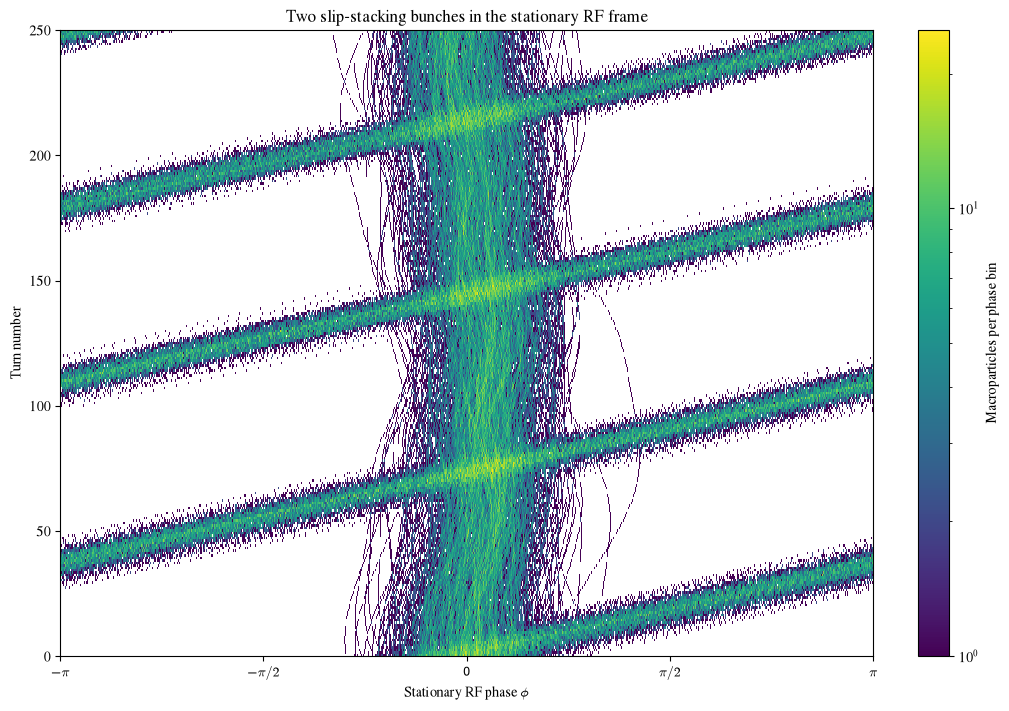

In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# Mask empty bins because LogNorm cannot display zero.
histogram_for_plot = np.ma.masked_less_equal(
    total_histogram,
    0,
)


fig, ax = plt.subplots(
    figsize=(10, 7),
    constrained_layout=True,
)


image = ax.imshow(
    histogram_for_plot,
    extent=[
        phase_bin_edges[0],
        phase_bin_edges[-1],
        density_turns[0],
        density_turns[-1],
    ],
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
    norm=LogNorm(
        vmin=1,
        vmax=total_histogram.max(),
    ),
)


colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label("Macroparticles per phase bin")


ax.set_xticks(
    [
        -np.pi,
        -np.pi / 2,
        0,
        np.pi / 2,
        np.pi,
    ],
    [
        r"$-\pi$",
        r"$-\pi/2$",
        r"$0$",
        r"$\pi/2$",
        r"$\pi$",
    ],
)

ax.set_xlabel(r"Stationary RF phase $\phi$")
ax.set_ylabel("Turn number")

ax.set_title(
    "Two slip-stacking bunches in the stationary RF frame"
)

ax.grid(False)

plt.show()

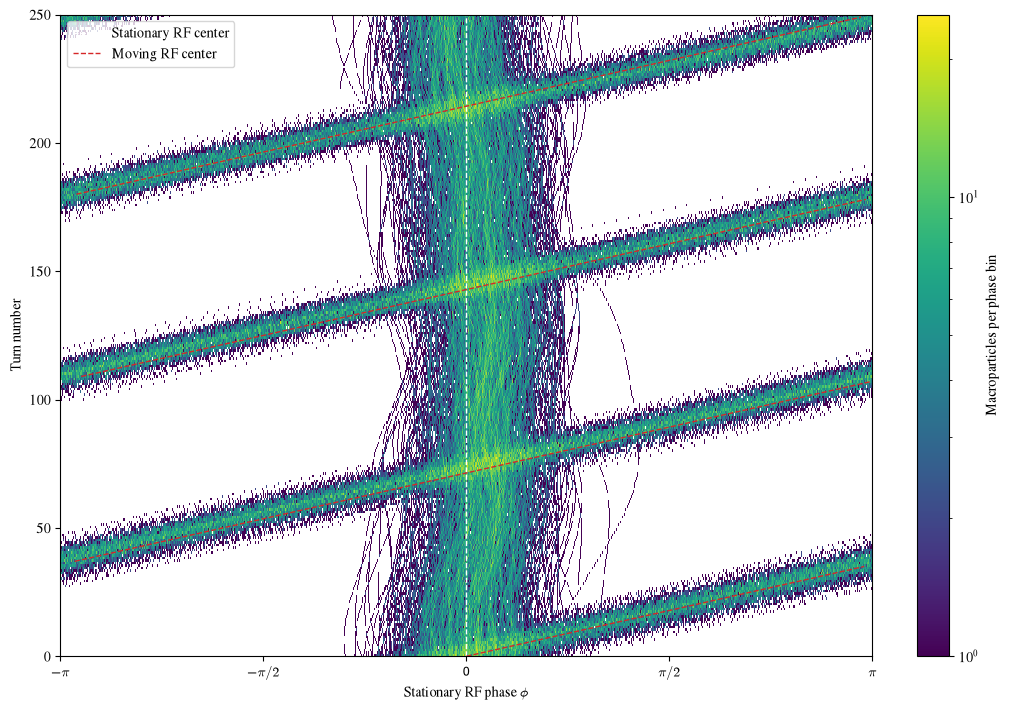

In [18]:
stationary_center_phase = np.zeros_like(density_turns)

moving_center_phase = wrap_phase(
    2.0
    * np.pi
    * nu_slip
    * density_turns
)


# Break the moving-center curve when it wraps through +/- pi.
moving_center_for_plot = moving_center_phase.copy()

phase_jumps = np.r_[
    False,
    np.abs(np.diff(moving_center_phase)) > np.pi,
]

moving_center_for_plot[phase_jumps] = np.nan


fig, ax = plt.subplots(
    figsize=(10, 7),
    constrained_layout=True,
)

image = ax.imshow(
    histogram_for_plot,
    extent=[
        phase_bin_edges[0],
        phase_bin_edges[-1],
        density_turns[0],
        density_turns[-1],
    ],
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
    norm=LogNorm(
        vmin=1,
        vmax=total_histogram.max(),
    ),
)

ax.plot(
    stationary_center_phase,
    density_turns,
    "--",
    color="white",
    linewidth=1.0,
    label="Stationary RF center",
)

ax.plot(
    moving_center_for_plot,
    density_turns,
    "--",
    color="tab:red",
    linewidth=1.0,
    label="Moving RF center",
)

fig.colorbar(
    image,
    ax=ax,
    label="Macroparticles per phase bin",
)

ax.set_xlim(-np.pi, np.pi)

ax.set_xticks(
    [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
    [
        r"$-\pi$",
        r"$-\pi/2$",
        r"$0$",
        r"$\pi/2$",
        r"$\pi$",
    ],
)

ax.set_xlabel(r"Stationary RF phase $\phi$")
ax.set_ylabel("Turn number")
ax.legend()
ax.grid(False)

plt.show()

In [19]:
f_rf = 52.8e6  # Hz

macro_delta_t_ns = (
    -macro_phi_wrapped
    / (2.0 * np.pi * f_rf)
    * 1e9
)

half_rf_period_ns = (
    0.5 / f_rf * 1e9
)

delta_t_range_ns = (
    -half_rf_period_ns,
    half_rf_period_ns,
)

print(
    "RF time window:",
    delta_t_range_ns,
    "ns",
)

RF time window: (-9.46969696969697, 9.46969696969697) ns


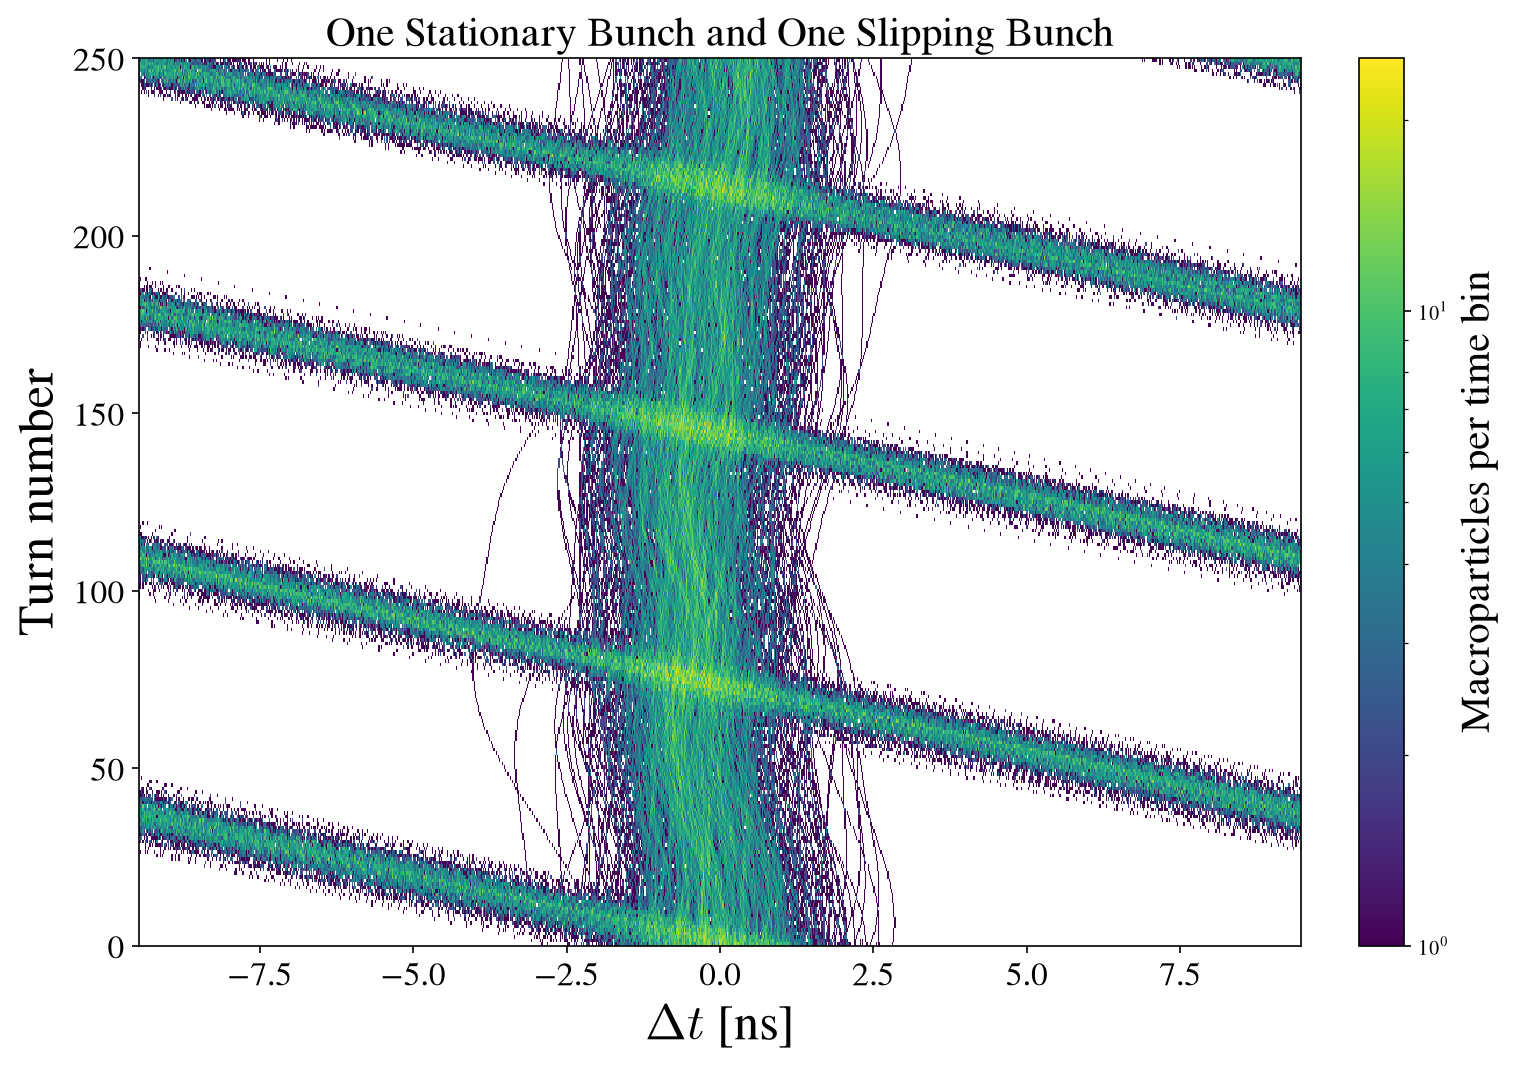

In [26]:
delta_t_histogram, delta_t_bin_edges = histogram_over_turns(
    macro_delta_t_ns,
    bin_count=bunch_bin_count,
    value_range=delta_t_range_ns,
)

delta_t_histogram_for_plot = np.ma.masked_less_equal(
    delta_t_histogram,
    0,
)


fig, ax = plt.subplots(
    figsize=(10, 7),
    constrained_layout=True,
)

image = ax.imshow(
    delta_t_histogram_for_plot,
    extent=[
        delta_t_bin_edges[0],
        delta_t_bin_edges[-1],
        density_turns[0],
        density_turns[-1],
    ],
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
    norm=LogNorm(
        vmin=1,
        vmax=delta_t_histogram.max(),
    ),
)

cb =fig.colorbar(
    image,
    ax=ax,
    label="Macroparticles per time bin",
)

cb.set_label("Macroparticles per time bin", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xlabel(r"$\Delta t$ [ns]", fontsize=24)
ax.set_ylabel("Turn number", fontsize=24)

ax.set_title(
    "One Stationary Bunch and One Slipping Bunch",
    fontsize=20
)

ax.grid(False)


fig.set_dpi(150)
plt.show()

In [21]:
84*20/(588*8.6e-3*89.8e3)

0.003699620418945016